In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [22]:
IMG_SIZE = 224
BATCH_SIZE = 16        # small batch = better for few data
EPOCHS = 30
LEARNING_RATE = 1e-4

TRAIN_DIR = 'E:\ec300\Oral cancer Dataset 2.0\\train'
VALID_DIR = "E:\ec300\Oral cancer Dataset 2.0\\valid"

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)


In [24]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

print(train_generator.class_indices)


Found 650 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
{'cancer': 0, 'normal': 1}


In [25]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all VGG16 layers
for layer in base_model.layers:
    layer.trainable = False


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)


In [27]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "oral_cancer_vgg16_best.h5",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [29]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4477 - loss: 0.7950

41/41 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.4815 - loss: 0.7858 - val_accuracy: 0.5133 - val_loss: 0.6702
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5631 - loss: 0.7089

41/41 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.5585 - loss: 0.7108 - val_accuracy: 0.7200 - val_loss: 0.6416
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6016 - loss: 0.6888

41/41 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.5908 - loss: 0.6815 - val_accuracy: 0.7967 - val_loss: 0.6220
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.5923 - loss: 0.6735 - val_accuracy: 0.7433 - val_loss: 0.6051
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.6031 - loss: 0.6572 - val_accuracy: 0.7433 - val_loss: 0.5898
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.6585 - loss: 0.6160 - val_accuracy: 0.7900 - val_loss: 0.5742
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 105s 3s/step - accuracy: 0.6692 - loss: 0.6222 - val_accuracy: 0.7767 - val_loss: 0.5636
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6646 - loss: 0.6047 - val_accuracy: 0.7500 - val_loss: 0.5550
Epoch 9/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.7262 - loss: 0.5771 - val_accuracy: 0.7567 - val_loss: 0.5453
Epoch 10/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.7308 - loss: 0.5601 - val_accuracy: 0.7800 - val_loss: 0.5

41/41 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.7292 - loss: 0.5613 - val_accuracy: 0.8000 - val_loss: 0.5220
Epoch 12/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.7323 - loss: 0.5471 - val_accuracy: 0.7833 - val_loss: 0.5190
Epoch 13/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.7369 - loss: 0.5510 - val_accuracy: 0.7733 - val_loss: 0.5140
Epoch 14/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7462 - loss: 0.5294 - val_accuracy: 0.8000 - val_loss: 0.5049
Epoch 15/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7615 - loss: 0.5125 - val_accuracy: 0.7533 - val_loss: 0.5081
Epoch 16/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.7508 - loss: 0.5201 - val_accuracy: 0.7900 - val_loss: 0.4961
Epoch 17/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7754 - loss: 0.5003

41/41 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.7785 - loss: 0.4994 - val_accuracy: 0.8100 - val_loss: 0.4896
Epoch 18/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7765 - loss: 0.4981

41/41 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.7800 - loss: 0.4936 - val_accuracy: 0.8167 - val_loss: 0.4842
Epoch 19/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.7800 - loss: 0.4961 - val_accuracy: 0.8133 - val_loss: 0.4762
Epoch 20/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.7877 - loss: 0.4709 - val_accuracy: 0.8133 - val_loss: 0.4712
Epoch 21/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8046 - loss: 0.4724 - val_accuracy: 0.8133 - val_loss: 0.4715
Epoch 22/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7923 - loss: 0.4633 - val_accuracy: 0.8100 - val_loss: 0.4710
Epoch 23/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8106 - loss: 0.4545

41/41 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8123 - loss: 0.4624 - val_accuracy: 0.8200 - val_loss: 0.4640
Epoch 24/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 880s 22s/step - accuracy: 0.8215 - loss: 0.4587 - val_accuracy: 0.8033 - val_loss: 0.4571
Epoch 25/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7954 - loss: 0.4603 - val_accuracy: 0.7967 - val_loss: 0.4664
Epoch 26/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.8062 - loss: 0.4414 - val_accuracy: 0.8200 - val_loss: 0.4566
Epoch 27/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.8277 - loss: 0.4353 - val_accuracy: 0.8167 - val_loss: 0.4569
Epoch 28/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.8046 - loss: 0.4382 - val_accuracy: 0.8200 - val_loss: 0.4517
Epoch 29/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8165 - loss: 0.4353

41/41 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.8123 - loss: 0.4365 - val_accuracy: 0.8233 - val_loss: 0.4518
Epoch 30/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8617 - loss: 0.4059

41/41 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8385 - loss: 0.4214 - val_accuracy: 0.8300 - val_loss: 0.4503


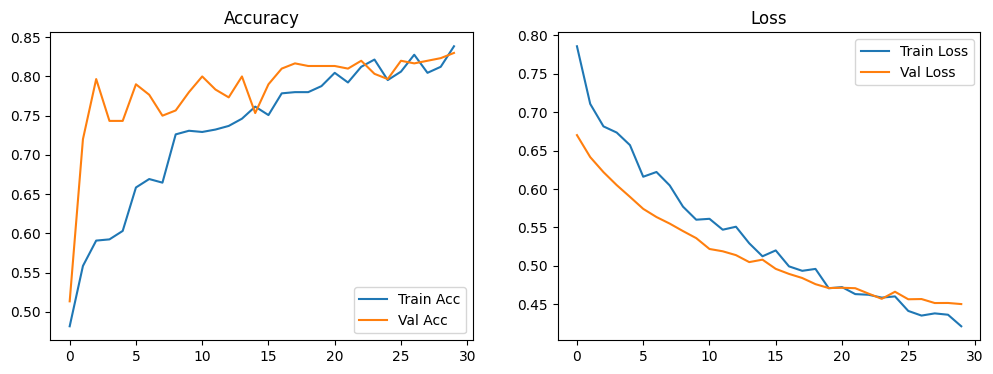

In [30]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [31]:
model.save("oral_cancer_vgg16_final.h5")
